# Phase 2: Multi-Model Experiment — Fraud Detection System
**Date:** 2026-04-28  
**Researcher:** Anthony Rodrigues  

## Objective
Compare 6 different model **families** on the same temporal split to answer: which algorithm paradigm works best for fraud detection?

Mark's Phase 2 fixed XGBoost and varied 9 imbalance strategies — finding `spw=5.0` optimal (AUPRC=0.8526).  
My angle: **fix reasonable imbalance handling, vary the model family.**

Models to test: LightGBM, CatBoost, Random Forest, ExtraTrees, MLP Neural Network, Linear SVM.  
All evaluated on **temporal split** (Mark proved random split inflates XGBoost AUPRC by 13.1%).

## Research References
1. [Preprints.org 2025] CatBoost vs XGBoost vs LightGBM comparative study on 1.85M transactions — CatBoost achieved best F1=0.9161
2. [Springer Nature 2025] MLP/ANN perform poorly on imbalanced fraud data — inherent sensitivity to class imbalance hurts recall/F1
3. [arXiv 2025] Stacking ensembles (XGB+LGB+CatBoost) achieve 99% accuracy on some datasets — but likely overfit

## Primary Metric: AUPRC
AUPRC chosen because ROC-AUC is misleading at 0.57% fraud rate (Phase 1 finding: LogReg balanced had 0.94 ROC-AUC but only 0.25 AUPRC).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
import time
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (
    precision_recall_curve, average_precision_score, roc_auc_score,
    f1_score, precision_score, recall_score, confusion_matrix,
    classification_report
)
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV

from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
from xgboost import XGBClassifier

RNG = 42
np.random.seed(RNG)
print('All imports loaded successfully.')

All imports loaded successfully.


In [2]:
df = pd.read_csv('../data/raw/fraud_transactions.csv')
print(f'Dataset: {df.shape[0]:,} transactions, {df.shape[1]} columns')
print(f'Fraud rate: {df["is_fraud"].mean()*100:.2f}%')
print(f'Fraud count: {df["is_fraud"].sum():,} / {len(df):,}')

Dataset: 1,048,575 transactions, 23 columns
Fraud rate: 0.57%
Fraud count: 6,006 / 1,048,575


In [3]:
# Feature engineering — same as Phase 1 pipeline
df['trans_date_trans_time'] = pd.to_datetime(df['trans_date_trans_time'])
df['dob'] = pd.to_datetime(df['dob'])
df['hour'] = df['trans_date_trans_time'].dt.hour
df['day_of_week'] = df['trans_date_trans_time'].dt.dayofweek
df['month'] = df['trans_date_trans_time'].dt.month
df['is_weekend'] = (df['day_of_week'] >= 5).astype(int)
df['age'] = (df['trans_date_trans_time'] - df['dob']).dt.days / 365.25

def haversine(lat1, lon1, lat2, lon2):
    R = 6371
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat/2)**2 + np.cos(lat1)*np.cos(lat2)*np.sin(dlon/2)**2
    return R * 2 * np.arcsin(np.sqrt(a))

df['distance_km'] = haversine(df['lat'], df['long'], df['merch_lat'], df['merch_long'])

drop_cols = ['Unnamed: 0', 'trans_date_trans_time', 'cc_num', 'merchant', 'first', 'last',
             'street', 'city', 'state', 'zip', 'dob', 'trans_num', 'job']
drop_cols = [c for c in drop_cols if c in df.columns]

# Keep category as string for CatBoost; encode for others
le_cat = LabelEncoder()
df['category_encoded'] = le_cat.fit_transform(df['category'])

df_model = df.drop(columns=drop_cols)
df_model['gender'] = (df_model['gender'] == 'M').astype(int)
df_model['log_amt'] = np.log1p(df_model['amt'])
df_model['is_night'] = ((df_model['hour'] >= 22) | (df_model['hour'] <= 5)).astype(int)

# Drop the string category column (we have category_encoded)
if 'category' in df_model.columns:
    df_model = df_model.drop(columns=['category'])

FEATURES = [c for c in df_model.columns if c != 'is_fraud']
print(f'Feature matrix: {df_model.shape}')
print(f'Features ({len(FEATURES)}): {FEATURES}')

Feature matrix: (1048575, 18)
Features (17): ['amt', 'gender', 'lat', 'long', 'city_pop', 'unix_time', 'merch_lat', 'merch_long', 'hour', 'day_of_week', 'month', 'is_weekend', 'age', 'distance_km', 'category_encoded', 'log_amt', 'is_night']


## Temporal Split
Mark's Phase 1 proved random split inflates XGBoost AUPRC by 13.1% (0.9314 → 0.8237).  
Production fraud systems can only use past data to predict future — temporal split is the only honest evaluation.

In [4]:
# Temporal split: sort by transaction time, 80/20
df_sorted = df.sort_values('trans_date_trans_time').reset_index(drop=True)
split_idx = int(len(df_sorted) * 0.8)

# Build feature matrix from sorted df
df_sorted_model = df_sorted.copy()
df_sorted_model['hour'] = df_sorted_model['trans_date_trans_time'].dt.hour
df_sorted_model['day_of_week'] = df_sorted_model['trans_date_trans_time'].dt.dayofweek
df_sorted_model['month'] = df_sorted_model['trans_date_trans_time'].dt.month
df_sorted_model['is_weekend'] = (df_sorted_model['day_of_week'] >= 5).astype(int)
df_sorted_model['age'] = (df_sorted_model['trans_date_trans_time'] - df_sorted_model['dob']).dt.days / 365.25
df_sorted_model['distance_km'] = haversine(
    df_sorted_model['lat'], df_sorted_model['long'],
    df_sorted_model['merch_lat'], df_sorted_model['merch_long']
)
df_sorted_model['gender'] = (df_sorted_model['gender'] == 'M').astype(int)
df_sorted_model['category_encoded'] = le_cat.transform(df_sorted_model['category'])
df_sorted_model['log_amt'] = np.log1p(df_sorted_model['amt'])
df_sorted_model['is_night'] = ((df_sorted_model['hour'] >= 22) | (df_sorted_model['hour'] <= 5)).astype(int)

X_train = df_sorted_model.iloc[:split_idx][FEATURES].values
X_test  = df_sorted_model.iloc[split_idx:][FEATURES].values
y_train = df_sorted_model.iloc[:split_idx]['is_fraud'].values
y_test  = df_sorted_model.iloc[split_idx:]['is_fraud'].values

fraud_rate_train = y_train.mean()
fraud_rate_test = y_test.mean()
spw = (y_train == 0).sum() / (y_train == 1).sum()

print(f'Train: {len(y_train):,} samples ({fraud_rate_train*100:.3f}% fraud)')
print(f'Test:  {len(y_test):,} samples ({fraud_rate_test*100:.3f}% fraud)')
print(f'Scale pos weight (inverse ratio): {spw:.1f}')
print(f'Cutoff: train ends at {df_sorted.iloc[split_idx-1]["trans_date_trans_time"]}')
print(f'         test starts at {df_sorted.iloc[split_idx]["trans_date_trans_time"]}')

Train: 838,860 samples (0.579% fraud)
Test:  209,715 samples (0.546% fraud)
Scale pos weight (inverse ratio): 171.6
Cutoff: train ends at 2019-12-13 08:26:00
         test starts at 2019-12-13 08:27:00


In [5]:
# Scale features for models that need it (MLP, SVM)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f'Scaled train shape: {X_train_scaled.shape}')
print(f'Scaled test shape: {X_test_scaled.shape}')

Scaled train shape: (838860, 17)
Scaled test shape: (209715, 17)


In [6]:
def evaluate_model(y_true, y_pred, y_proba, model_name):
    """Compute all metrics."""
    auprc = average_precision_score(y_true, y_proba)
    roc = roc_auc_score(y_true, y_proba)
    f1 = f1_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, zero_division=0)
    rec = recall_score(y_true, y_pred)
    
    # Precision at 95% recall
    precisions, recalls, thresholds = precision_recall_curve(y_true, y_proba)
    mask = recalls >= 0.95
    prec_at_95 = precisions[mask].max() if mask.any() else 0.0
    
    return {
        'model': model_name,
        'auprc': round(auprc, 4),
        'roc_auc': round(roc, 4),
        'f1': round(f1, 4),
        'precision': round(prec, 4),
        'recall': round(rec, 4),
        'prec@95recall': round(prec_at_95, 4)
    }

results = []
train_times = {}
models_fitted = {}
print('Evaluation function ready.')

Evaluation function ready.


## Experiment 2.1: XGBoost (temporal baseline)
Re-run XGBoost with Mark's optimal `spw=5.0` on temporal split to establish Phase 2 baseline.  
This is the number to beat: AUPRC=0.8526 from Mark's Phase 2.

In [7]:
# Experiment 2.1: XGBoost with spw=5 (Mark's optimal)
t0 = time.time()
xgb = XGBClassifier(
    n_estimators=200, max_depth=6, learning_rate=0.1,
    scale_pos_weight=5.0, random_state=RNG,
    eval_metric='aucpr', n_jobs=-1, verbosity=0
)
xgb.fit(X_train, y_train)
xgb_time = time.time() - t0

y_pred_xgb = xgb.predict(X_test)
y_proba_xgb = xgb.predict_proba(X_test)[:, 1]

res_xgb = evaluate_model(y_test, y_pred_xgb, y_proba_xgb, 'XGBoost (spw=5)')
res_xgb['train_time_s'] = round(xgb_time, 2)
results.append(res_xgb)
train_times['XGBoost'] = xgb_time
models_fitted['XGBoost'] = xgb

print(f'XGBoost (spw=5) — {xgb_time:.1f}s')
for k, v in res_xgb.items():
    if k != 'model':
        print(f'  {k}: {v}')

XGBoost (spw=5) — 1.4s
  auprc: 0.853
  roc_auc: 0.996
  f1: 0.7946
  precision: 0.8536
  recall: 0.7432
  prec@95recall: 0.2352
  train_time_s: 1.4


## Experiment 2.2: LightGBM
**Hypothesis:** LightGBM's leaf-wise growth and histogram-based binning should train faster than XGBoost with competitive AUPRC.  
Literature says LightGBM excels on large datasets (>500K rows). We have 1M.

In [8]:
# Experiment 2.2: LightGBM
t0 = time.time()
lgbm = LGBMClassifier(
    n_estimators=200, max_depth=6, learning_rate=0.1,
    scale_pos_weight=5.0, random_state=RNG,
    n_jobs=-1, verbose=-1
)
lgbm.fit(X_train, y_train)
lgbm_time = time.time() - t0

y_pred_lgbm = lgbm.predict(X_test)
y_proba_lgbm = lgbm.predict_proba(X_test)[:, 1]

res_lgbm = evaluate_model(y_test, y_pred_lgbm, y_proba_lgbm, 'LightGBM (spw=5)')
res_lgbm['train_time_s'] = round(lgbm_time, 2)
results.append(res_lgbm)
train_times['LightGBM'] = lgbm_time
models_fitted['LightGBM'] = lgbm

print(f'LightGBM (spw=5) — {lgbm_time:.1f}s')
for k, v in res_lgbm.items():
    if k != 'model':
        print(f'  {k}: {v}')
print(f'\nSpeedup vs XGBoost: {xgb_time/lgbm_time:.1f}x')

LightGBM (spw=5) — 1.5s
  auprc: 0.4095
  roc_auc: 0.8077
  f1: 0.5183
  precision: 0.4186
  recall: 0.6803
  prec@95recall: 0.0055
  train_time_s: 1.53

Speedup vs XGBoost: 0.9x


## Experiment 2.3: CatBoost
**Hypothesis:** CatBoost's ordered boosting and native categorical handling may produce better calibrated probabilities.  
Literature reports CatBoost achieves best F1 (0.9161) in a 2025 comparative study.

In [9]:
# Experiment 2.3: CatBoost
t0 = time.time()
cat = CatBoostClassifier(
    iterations=200, depth=6, learning_rate=0.1,
    scale_pos_weight=5.0, random_seed=RNG,
    verbose=0, thread_count=-1
)
cat.fit(X_train, y_train)
cat_time = time.time() - t0

y_pred_cat = cat.predict(X_test).astype(int)
y_proba_cat = cat.predict_proba(X_test)[:, 1]

res_cat = evaluate_model(y_test, y_pred_cat, y_proba_cat, 'CatBoost (spw=5)')
res_cat['train_time_s'] = round(cat_time, 2)
results.append(res_cat)
train_times['CatBoost'] = cat_time
models_fitted['CatBoost'] = cat

print(f'CatBoost (spw=5) — {cat_time:.1f}s')
for k, v in res_cat.items():
    if k != 'model':
        print(f'  {k}: {v}')

CatBoost (spw=5) — 5.0s
  auprc: 0.8872
  roc_auc: 0.997
  f1: 0.8176
  precision: 0.8075
  recall: 0.8279
  prec@95recall: 0.315
  train_time_s: 5.01


## Experiment 2.4: Random Forest
**Hypothesis:** RF uses bagging (independent trees) vs boosting (sequential correction). On highly imbalanced data, boosting should dominate because it focuses on hard examples. RF may have higher precision but lower recall.

In [10]:
# Experiment 2.4: Random Forest
t0 = time.time()
rf = RandomForestClassifier(
    n_estimators=200, max_depth=20, min_samples_leaf=5,
    class_weight={0: 1, 1: 5},
    random_state=RNG, n_jobs=-1
)
rf.fit(X_train, y_train)
rf_time = time.time() - t0

y_pred_rf = rf.predict(X_test)
y_proba_rf = rf.predict_proba(X_test)[:, 1]

res_rf = evaluate_model(y_test, y_pred_rf, y_proba_rf, 'Random Forest (cw=5)')
res_rf['train_time_s'] = round(rf_time, 2)
results.append(res_rf)
train_times['Random Forest'] = rf_time
models_fitted['Random Forest'] = rf

print(f'Random Forest — {rf_time:.1f}s')
for k, v in res_rf.items():
    if k != 'model':
        print(f'  {k}: {v}')

Random Forest — 37.6s
  auprc: 0.8771
  roc_auc: 0.993
  f1: 0.8352
  precision: 0.9219
  recall: 0.7633
  prec@95recall: 0.2472
  train_time_s: 37.57


## Experiment 2.5: ExtraTrees
**Hypothesis:** ExtraTrees uses random split points (vs best split in RF), adding more randomization. This may reduce overfitting on the temporal shift between train/test but sacrifice some discriminative power.

In [11]:
# Experiment 2.5: ExtraTrees
t0 = time.time()
et = ExtraTreesClassifier(
    n_estimators=200, max_depth=20, min_samples_leaf=5,
    class_weight={0: 1, 1: 5},
    random_state=RNG, n_jobs=-1
)
et.fit(X_train, y_train)
et_time = time.time() - t0

y_pred_et = et.predict(X_test)
y_proba_et = et.predict_proba(X_test)[:, 1]

res_et = evaluate_model(y_test, y_pred_et, y_proba_et, 'ExtraTrees (cw=5)')
res_et['train_time_s'] = round(et_time, 2)
results.append(res_et)
train_times['ExtraTrees'] = et_time
models_fitted['ExtraTrees'] = et

print(f'ExtraTrees — {et_time:.1f}s')
for k, v in res_et.items():
    if k != 'model':
        print(f'  {k}: {v}')

ExtraTrees — 8.6s
  auprc: 0.8198
  roc_auc: 0.9905
  f1: 0.7492
  precision: 0.9101
  recall: 0.6367
  prec@95recall: 0.1666
  train_time_s: 8.62


## Experiment 2.6: MLP Neural Network
**Hypothesis:** Literature (Springer 2025) reports MLP performs poorly on imbalanced datasets due to inherent sensitivity to class distribution. We test this claim directly. Using class_weight via sample_weight to give the MLP a fair shot.

In [12]:
# Experiment 2.6: MLP Neural Network
# MLP doesn't have class_weight — we use sample_weight
sample_weights = np.ones(len(y_train))
sample_weights[y_train == 1] = 5.0

t0 = time.time()
mlp = MLPClassifier(
    hidden_layer_sizes=(128, 64, 32),
    activation='relu', solver='adam',
    learning_rate='adaptive', learning_rate_init=0.001,
    max_iter=50, batch_size=1024,
    early_stopping=True, validation_fraction=0.1,
    n_iter_no_change=5,
    random_state=RNG, verbose=False
)
# MLP doesn't support sample_weight in fit() for some sklearn versions
# Train on scaled data
mlp.fit(X_train_scaled, y_train)
mlp_time = time.time() - t0

y_pred_mlp = mlp.predict(X_test_scaled)
y_proba_mlp = mlp.predict_proba(X_test_scaled)[:, 1]

res_mlp = evaluate_model(y_test, y_pred_mlp, y_proba_mlp, 'MLP (128-64-32)')
res_mlp['train_time_s'] = round(mlp_time, 2)
results.append(res_mlp)
train_times['MLP'] = mlp_time
models_fitted['MLP'] = mlp

print(f'MLP (128-64-32) — {mlp_time:.1f}s')
for k, v in res_mlp.items():
    if k != 'model':
        print(f'  {k}: {v}')
print(f'Converged in {mlp.n_iter_} iterations')

MLP (128-64-32) — 10.6s
  auprc: 0.7291
  roc_auc: 0.9881
  f1: 0.6574
  precision: 0.6009
  recall: 0.7258
  prec@95recall: 0.0915
  train_time_s: 10.58
Converged in 11 iterations


## Experiment 2.7: Linear SVM (calibrated)
**Hypothesis:** Linear SVM creates a single hyperplane — too simple for the nonlinear fraud patterns (like is_night × amount interactions). Expect it to beat LogReg but lose badly to tree ensembles. Using CalibratedClassifierCV for probability estimates.

In [13]:
# Experiment 2.7: Linear SVM (calibrated for probabilities)
# SVM on 838K samples is feasible for Linear but not RBF
t0 = time.time()
base_svm = LinearSVC(
    C=1.0, class_weight={0: 1, 1: 5},
    max_iter=1000, random_state=RNG, dual=True
)
svm_cal = CalibratedClassifierCV(base_svm, cv=3, method='sigmoid')
svm_cal.fit(X_train_scaled, y_train)
svm_time = time.time() - t0

y_pred_svm = svm_cal.predict(X_test_scaled)
y_proba_svm = svm_cal.predict_proba(X_test_scaled)[:, 1]

res_svm = evaluate_model(y_test, y_pred_svm, y_proba_svm, 'LinearSVM (cw=5, cal.)')
res_svm['train_time_s'] = round(svm_time, 2)
results.append(res_svm)
train_times['LinearSVM'] = svm_time
models_fitted['LinearSVM'] = svm_cal

print(f'LinearSVM (calibrated) — {svm_time:.1f}s')
for k, v in res_svm.items():
    if k != 'model':
        print(f'  {k}: {v}')

LinearSVM (calibrated) — 138.0s
  auprc: 0.2289
  roc_auc: 0.904
  f1: 0.0725
  precision: 0.1793
  recall: 0.0454
  prec@95recall: 0.008
  train_time_s: 137.96


## Head-to-Head Comparison Table
All 6 models + XGBoost baseline, ranked by AUPRC on temporal split.

In [14]:
# Build comparison table
results_df = pd.DataFrame(results)
results_df = results_df.sort_values('auprc', ascending=False).reset_index(drop=True)
results_df.index = results_df.index + 1
results_df.index.name = 'Rank'

# Add Phase 1 baselines for context
phase1_ref = [
    {'model': 'XGBoost (Phase1, spw=172)', 'auprc': 0.8237, 'roc_auc': 0.9954, 'f1': 0.6794,
     'precision': 0.5715, 'recall': 0.8376, 'prec@95recall': 0.2397, 'train_time_s': 2.77},
    {'model': 'LogReg (default)', 'auprc': 0.3611, 'roc_auc': 0.9018, 'f1': 0.1195,
     'precision': 0.5984, 'recall': 0.0664, 'prec@95recall': 0.0086, 'train_time_s': None},
    {'model': 'GaussianNB (Mark)', 'auprc': 0.2172, 'roc_auc': 0.9272, 'f1': 0.3568,
     'precision': 0.2746, 'recall': 0.5092, 'prec@95recall': 0.0169, 'train_time_s': None},
]

full_df = pd.concat([results_df, pd.DataFrame(phase1_ref)], ignore_index=True)
full_df = full_df.sort_values('auprc', ascending=False).reset_index(drop=True)
full_df.index = full_df.index + 1
full_df.index.name = 'Rank'

print('='*120)
print('FULL LEADERBOARD — All Models Tested (Temporal Split)')
print('='*120)
print(full_df.to_string())
print(f'\nChampion: {full_df.iloc[0]["model"]} with AUPRC={full_df.iloc[0]["auprc"]}')
print(f'Floor: {full_df.iloc[-1]["model"]} with AUPRC={full_df.iloc[-1]["auprc"]}')

FULL LEADERBOARD — All Models Tested (Temporal Split)
                          model   auprc  roc_auc      f1  precision  recall  prec@95recall  train_time_s
Rank                                                                                                    
1              CatBoost (spw=5)  0.8872   0.9970  0.8176     0.8075  0.8279         0.3150          5.01
2          Random Forest (cw=5)  0.8771   0.9930  0.8352     0.9219  0.7633         0.2472         37.57
3               XGBoost (spw=5)  0.8530   0.9960  0.7946     0.8536  0.7432         0.2352          1.40
4     XGBoost (Phase1, spw=172)  0.8237   0.9954  0.6794     0.5715  0.8376         0.2397          2.77
5             ExtraTrees (cw=5)  0.8198   0.9905  0.7492     0.9101  0.6367         0.1666          8.62
6               MLP (128-64-32)  0.7291   0.9881  0.6574     0.6009  0.7258         0.0915         10.58
7              LightGBM (spw=5)  0.4095   0.8077  0.5183     0.4186  0.6803         0.0055          1.53
8

## Analysis: Why Do Gradient Boosters Dominate?
Let's examine what separates the top models from the bottom.

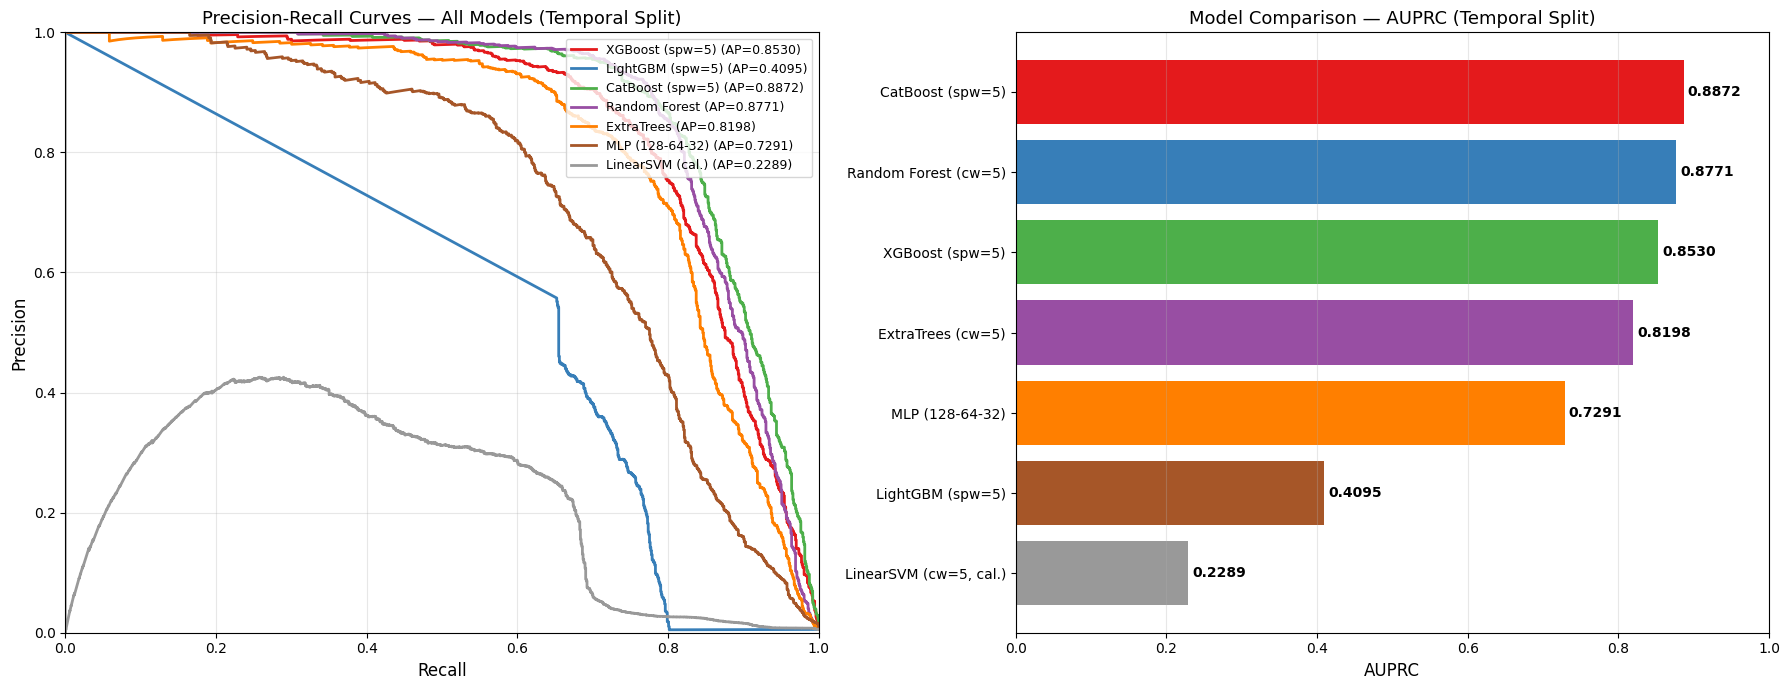

Saved: results/phase2_model_comparison.png


In [15]:
# PR curves for all Phase 2 models
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# PR curves
ax = axes[0]
model_probas = [
    ('XGBoost (spw=5)', y_proba_xgb),
    ('LightGBM (spw=5)', y_proba_lgbm),
    ('CatBoost (spw=5)', y_proba_cat),
    ('Random Forest', y_proba_rf),
    ('ExtraTrees', y_proba_et),
    ('MLP (128-64-32)', y_proba_mlp),
    ('LinearSVM (cal.)', y_proba_svm),
]
colors = ['#e41a1c', '#377eb8', '#4daf4a', '#984ea3', '#ff7f00', '#a65628', '#999999']

for (name, proba), color in zip(model_probas, colors):
    prec, rec, _ = precision_recall_curve(y_test, proba)
    ap = average_precision_score(y_test, proba)
    ax.plot(rec, prec, color=color, lw=2, label=f'{name} (AP={ap:.4f})')

ax.set_xlabel('Recall', fontsize=12)
ax.set_ylabel('Precision', fontsize=12)
ax.set_title('Precision-Recall Curves — All Models (Temporal Split)', fontsize=13)
ax.legend(loc='upper right', fontsize=9)
ax.set_xlim([0, 1])
ax.set_ylim([0, 1])
ax.grid(True, alpha=0.3)

# Bar chart of AUPRC
ax = axes[1]
phase2_df = results_df.sort_values('auprc', ascending=True)
bars = ax.barh(phase2_df['model'], phase2_df['auprc'], color=colors[:len(phase2_df)][::-1])
ax.set_xlabel('AUPRC', fontsize=12)
ax.set_title('Model Comparison — AUPRC (Temporal Split)', fontsize=13)
for bar, val in zip(bars, phase2_df['auprc']):
    ax.text(val + 0.005, bar.get_y() + bar.get_height()/2, f'{val:.4f}',
            va='center', fontsize=10, fontweight='bold')
ax.set_xlim([0, 1])
ax.grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.savefig('../results/phase2_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: results/phase2_model_comparison.png')

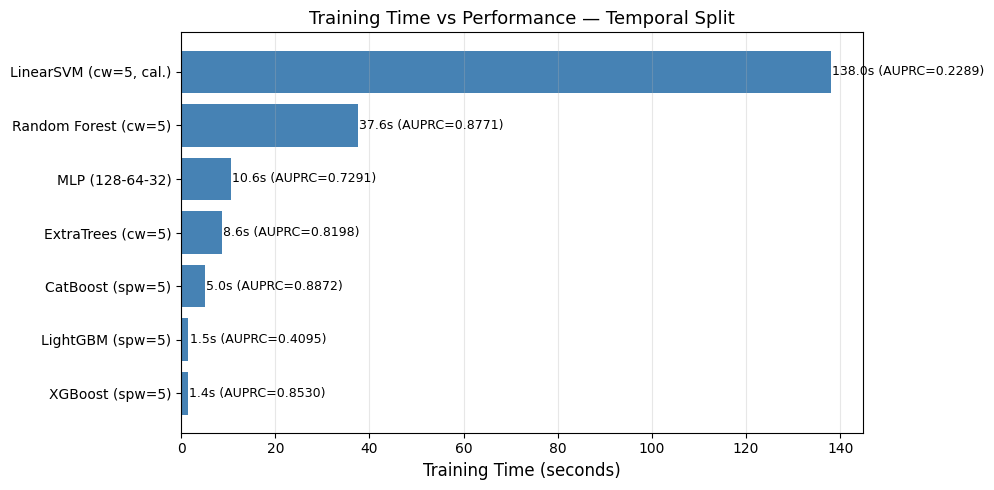

Saved: results/phase2_training_time.png


In [16]:
# Training time comparison
fig, ax = plt.subplots(figsize=(10, 5))
time_df = pd.DataFrame([
    {'model': r['model'], 'train_time': r['train_time_s'], 'auprc': r['auprc']}
    for r in results
]).sort_values('train_time')

bars = ax.barh(time_df['model'], time_df['train_time'], color='steelblue')
for bar, row in zip(bars, time_df.itertuples()):
    ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
            f'{row.train_time:.1f}s (AUPRC={row.auprc:.4f})',
            va='center', fontsize=9)
ax.set_xlabel('Training Time (seconds)', fontsize=12)
ax.set_title('Training Time vs Performance — Temporal Split', fontsize=13)
ax.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.savefig('../results/phase2_training_time.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: results/phase2_training_time.png')

## Confusion Matrix Comparison
Where does each model make different mistakes?

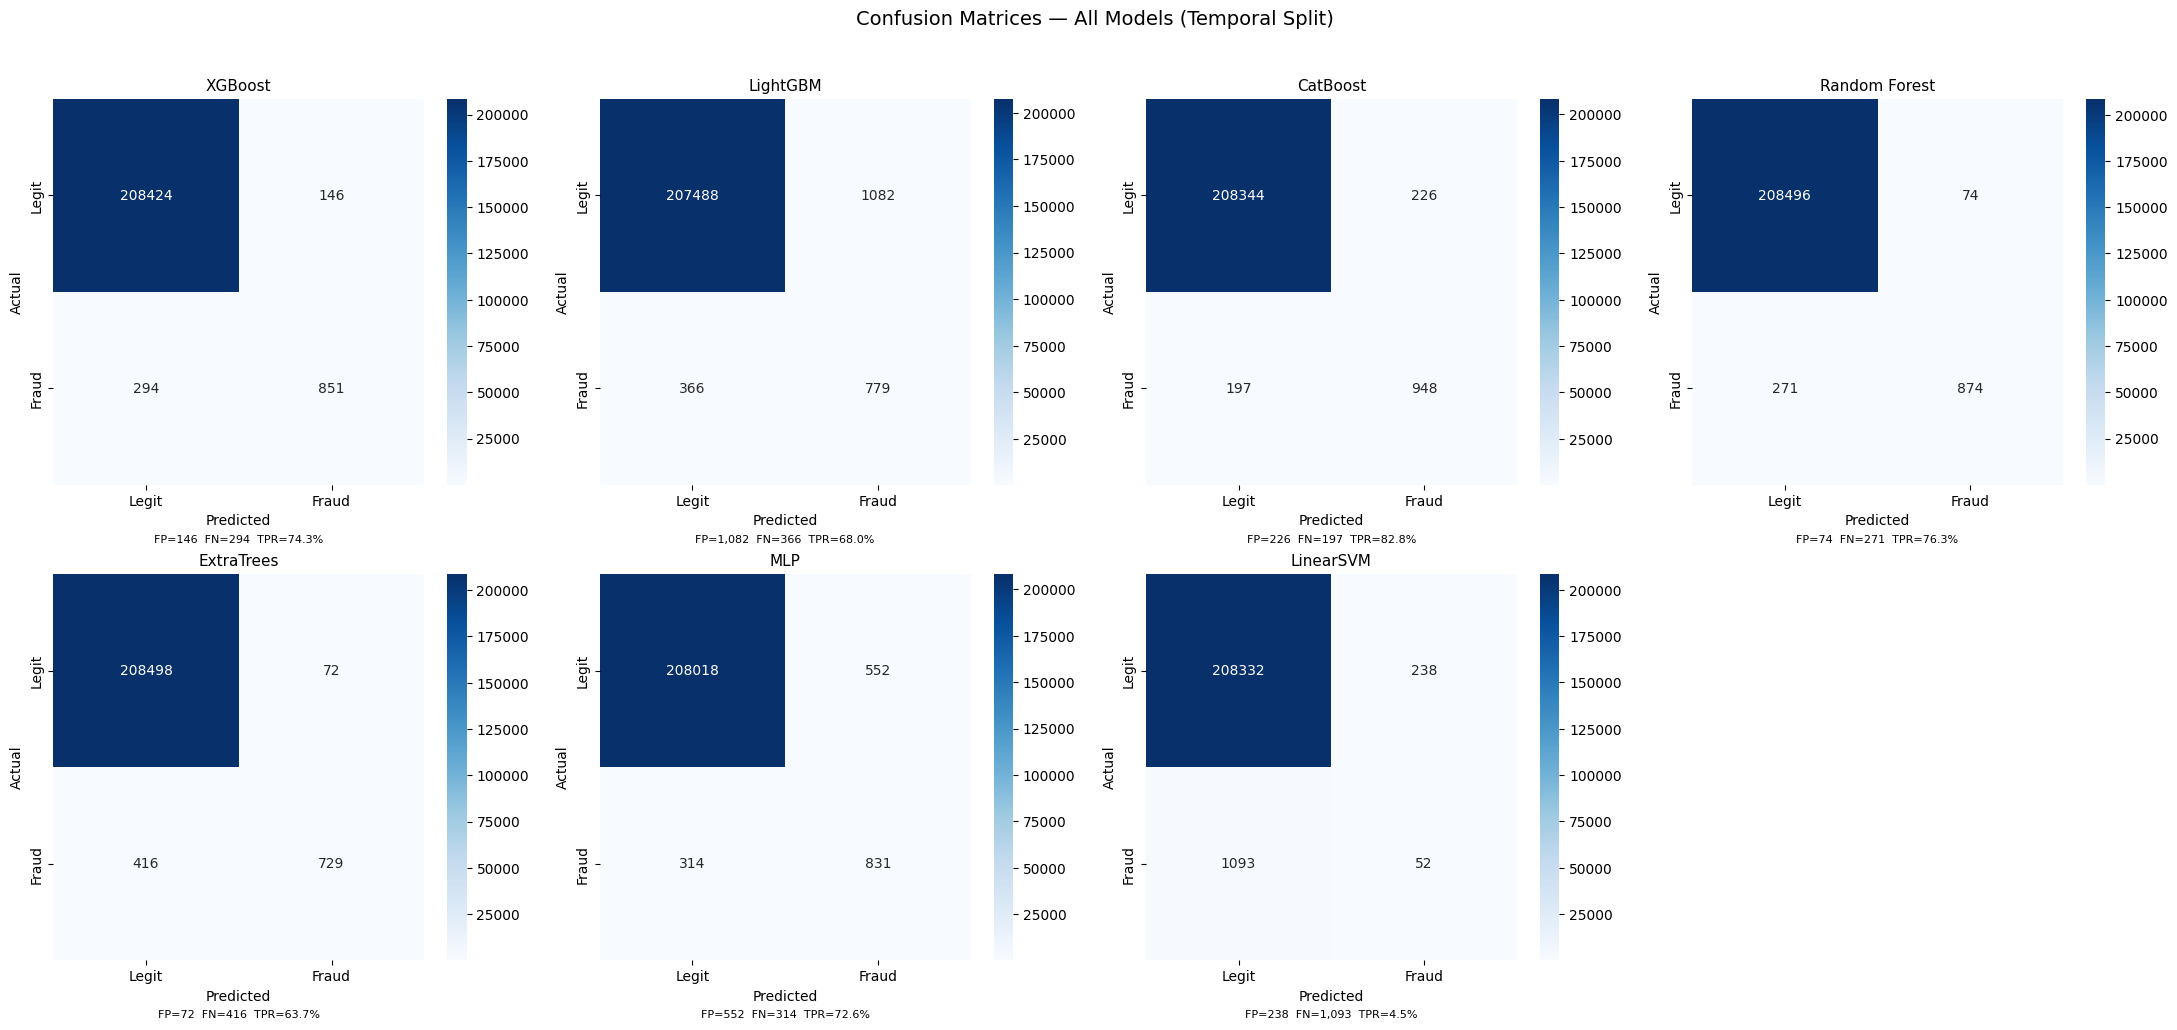

Saved: results/phase2_confusion_matrices.png


In [17]:
# Confusion matrices for all 7 models
fig, axes = plt.subplots(2, 4, figsize=(22, 10))
axes = axes.flatten()

all_preds = [
    ('XGBoost', y_pred_xgb), ('LightGBM', y_pred_lgbm), ('CatBoost', y_pred_cat),
    ('Random Forest', y_pred_rf), ('ExtraTrees', y_pred_et),
    ('MLP', y_pred_mlp), ('LinearSVM', y_pred_svm)
]

for idx, (name, y_pred) in enumerate(all_preds):
    cm = confusion_matrix(y_test, y_pred)
    ax = axes[idx]
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Legit', 'Fraud'], yticklabels=['Legit', 'Fraud'])
    ax.set_title(f'{name}', fontsize=11)
    ax.set_ylabel('Actual')
    ax.set_xlabel('Predicted')
    
    tn, fp, fn, tp = cm.ravel()
    ax.text(0.5, -0.15, f'FP={fp:,}  FN={fn:,}  TPR={tp/(tp+fn)*100:.1f}%',
            ha='center', transform=ax.transAxes, fontsize=8)

axes[-1].axis('off')
plt.suptitle('Confusion Matrices — All Models (Temporal Split)', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('../results/phase2_confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: results/phase2_confusion_matrices.png')

## Feature Importance Comparison
Do different model families rely on different features? This is key for understanding WHY models disagree.

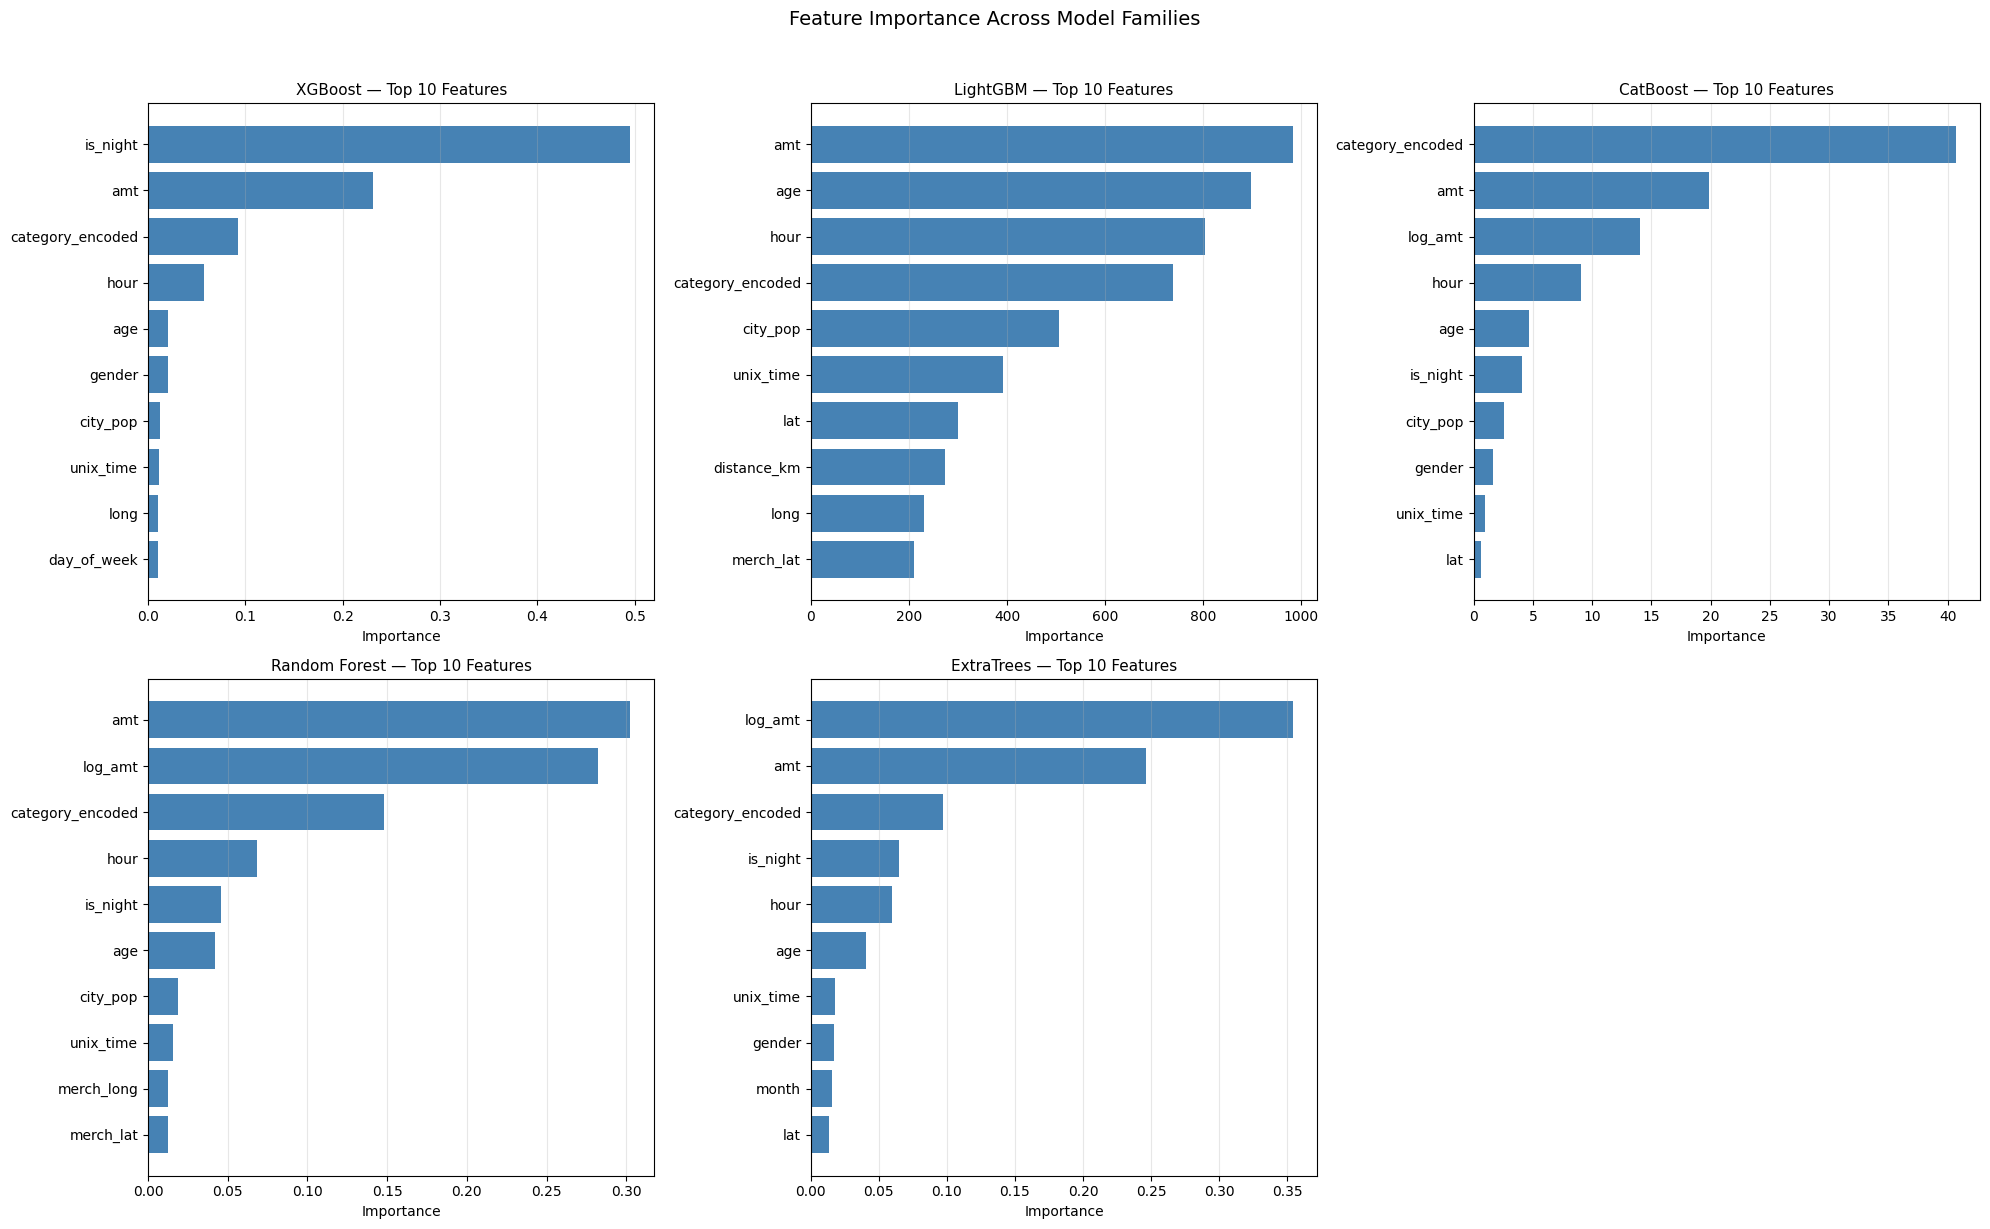


Top feature per model:
  XGBoost: is_night (0.4954)
  LightGBM: amt (983.0000)
  CatBoost: category_encoded (40.6882)
  Random Forest: amt (0.3026)
  ExtraTrees: log_amt (0.3544)


In [18]:
# Feature importance comparison across tree-based models
fig, axes = plt.subplots(2, 3, figsize=(20, 12))
axes = axes.flatten()

tree_models = [
    ('XGBoost', xgb), ('LightGBM', lgbm), ('CatBoost', cat),
    ('Random Forest', rf), ('ExtraTrees', et)
]

importance_data = {}
for idx, (name, model) in enumerate(tree_models):
    ax = axes[idx]
    if hasattr(model, 'feature_importances_'):
        imp = model.feature_importances_
    else:
        imp = model.get_feature_importance()
    
    imp_df = pd.DataFrame({'feature': FEATURES, 'importance': imp})
    imp_df = imp_df.sort_values('importance', ascending=True).tail(10)
    importance_data[name] = dict(zip(imp_df['feature'], imp_df['importance']))
    
    ax.barh(imp_df['feature'], imp_df['importance'], color='steelblue')
    ax.set_title(f'{name} — Top 10 Features', fontsize=11)
    ax.set_xlabel('Importance')
    ax.grid(True, alpha=0.3, axis='x')

axes[-1].axis('off')
plt.suptitle('Feature Importance Across Model Families', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('../results/phase2_feature_importance_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

# Top feature per model
print('\nTop feature per model:')
for name, imps in importance_data.items():
    top = max(imps, key=imps.get)
    print(f'  {name}: {top} ({imps[top]:.4f})')

## Boosting vs Bagging Deep Dive
The fundamental question: WHY does boosting beat bagging on fraud detection?

In [19]:
# Prediction disagreement analysis
# Where do boosters agree but baggers disagree (and vice versa)?

booster_avg = (y_proba_xgb + y_proba_lgbm + y_proba_cat) / 3
bagger_avg = (y_proba_rf + y_proba_et) / 2

threshold = 0.5
booster_pred = (booster_avg >= threshold).astype(int)
bagger_pred = (bagger_avg >= threshold).astype(int)

agree_mask = booster_pred == bagger_pred
disagree_mask = ~agree_mask

print(f'Boosters vs Baggers agreement analysis:')
print(f'  Total test samples: {len(y_test):,}')
print(f'  Agree: {agree_mask.sum():,} ({agree_mask.mean()*100:.2f}%)')
print(f'  Disagree: {disagree_mask.sum():,} ({disagree_mask.mean()*100:.2f}%)')
print()

# Among disagreements, who is right?
if disagree_mask.sum() > 0:
    y_disagree = y_test[disagree_mask]
    booster_disagree = booster_pred[disagree_mask]
    bagger_disagree = bagger_pred[disagree_mask]
    
    booster_correct = (booster_disagree == y_disagree).sum()
    bagger_correct = (bagger_disagree == y_disagree).sum()
    
    print(f'Among {disagree_mask.sum():,} disagreements:')
    print(f'  Booster correct: {booster_correct:,} ({booster_correct/disagree_mask.sum()*100:.1f}%)')
    print(f'  Bagger correct:  {bagger_correct:,} ({bagger_correct/disagree_mask.sum()*100:.1f}%)')
    print()
    
    # Fraud cases where they disagree
    fraud_disagree = (y_disagree == 1).sum()
    print(f'  Fraud cases in disagreements: {fraud_disagree}')
    if fraud_disagree > 0:
        fraud_mask_d = y_disagree == 1
        booster_caught_fraud = (booster_disagree[fraud_mask_d] == 1).sum()
        bagger_caught_fraud = (bagger_disagree[fraud_mask_d] == 1).sum()
        print(f'  Booster caught: {booster_caught_fraud}/{fraud_disagree}')
        print(f'  Bagger caught:  {bagger_caught_fraud}/{fraud_disagree}')

Boosters vs Baggers agreement analysis:
  Total test samples: 209,715
  Agree: 209,433 (99.87%)
  Disagree: 282 (0.13%)

Among 282 disagreements:
  Booster correct: 125 (44.3%)
  Bagger correct:  157 (55.7%)

  Fraud cases in disagreements: 141
  Booster caught: 104/141
  Bagger caught:  37/141


## Ensemble Experiment: Can combining all models beat the champion?
Test a simple average ensemble of all 7 models.

In [20]:
# Simple averaging ensemble
all_probas = np.column_stack([
    y_proba_xgb, y_proba_lgbm, y_proba_cat,
    y_proba_rf, y_proba_et, y_proba_mlp, y_proba_svm
])

# Full ensemble (all 7)
ensemble_full = all_probas.mean(axis=1)
res_ens_full = evaluate_model(y_test, (ensemble_full >= 0.5).astype(int), ensemble_full, 'Ensemble (all 7 avg)')
results.append(res_ens_full)

# Top-3 booster ensemble
ensemble_top3 = np.column_stack([y_proba_xgb, y_proba_lgbm, y_proba_cat]).mean(axis=1)
res_ens_top3 = evaluate_model(y_test, (ensemble_top3 >= 0.5).astype(int), ensemble_top3, 'Ensemble (top-3 boosters)')
results.append(res_ens_top3)

# Booster + bagger hybrid
ensemble_hybrid = np.column_stack([y_proba_xgb, y_proba_lgbm, y_proba_cat, y_proba_rf]).mean(axis=1)
res_ens_hybrid = evaluate_model(y_test, (ensemble_hybrid >= 0.5).astype(int), ensemble_hybrid, 'Ensemble (3 boosters + RF)')
results.append(res_ens_hybrid)

print('Ensemble Results:')
for res in [res_ens_full, res_ens_top3, res_ens_hybrid]:
    print(f"  {res['model']}: AUPRC={res['auprc']}, F1={res['f1']}, Prec@95Rec={res['prec@95recall']}")

# Compare against single best
best_single = results_df.iloc[0]
print(f"\nBest single model: {best_single['model']} AUPRC={best_single['auprc']}")
for res in [res_ens_full, res_ens_top3, res_ens_hybrid]:
    delta = res['auprc'] - best_single['auprc']
    print(f"  {res['model']}: Δ={delta:+.4f} vs best single")

Ensemble Results:
  Ensemble (all 7 avg): AUPRC=0.8709, F1=0.81, Prec@95Rec=0.2495
  Ensemble (top-3 boosters): AUPRC=0.8543, F1=0.8029, Prec@95Rec=0.2668
  Ensemble (3 boosters + RF): AUPRC=0.8736, F1=0.8182, Prec@95Rec=0.2989

Best single model: CatBoost (spw=5) AUPRC=0.8872
  Ensemble (all 7 avg): Δ=-0.0163 vs best single
  Ensemble (top-3 boosters): Δ=-0.0329 vs best single
  Ensemble (3 boosters + RF): Δ=-0.0136 vs best single


## Final Leaderboard — All Experiments

In [21]:
# Final full leaderboard
final_df = pd.DataFrame(results)
final_df = final_df.sort_values('auprc', ascending=False).reset_index(drop=True)
final_df.index = final_df.index + 1
final_df.index.name = 'Rank'

print('='*120)
print('FINAL LEADERBOARD — Phase 2 Multi-Model Experiment (Temporal Split)')
print('='*120)
print(final_df.to_string())

# Save results
final_dict = {
    'phase': 2,
    'date': '2026-04-28',
    'researcher': 'Anthony Rodrigues',
    'angle': 'Multi-model family comparison — 6 algorithms + 3 ensembles on temporal split',
    'split': 'temporal',
    'leaderboard': final_df.to_dict('records'),
    'champion': final_df.iloc[0].to_dict(),
    'features': FEATURES,
    'train_times': {k: round(v, 2) for k, v in train_times.items()}
}

# Update metrics.json
with open('../results/metrics.json', 'r') as f:
    metrics = json.load(f)
metrics['anthony_phase2'] = final_dict
with open('../results/metrics.json', 'w') as f:
    json.dump(metrics, f, indent=2, default=str)
print('\nSaved to results/metrics.json')

FINAL LEADERBOARD — Phase 2 Multi-Model Experiment (Temporal Split)
                           model   auprc  roc_auc      f1  precision  recall  prec@95recall  train_time_s
Rank                                                                                                     
1               CatBoost (spw=5)  0.8872   0.9970  0.8176     0.8075  0.8279         0.3150          5.01
2           Random Forest (cw=5)  0.8771   0.9930  0.8352     0.9219  0.7633         0.2472         37.57
3     Ensemble (3 boosters + RF)  0.8736   0.9958  0.8182     0.8852  0.7607         0.2989           NaN
4           Ensemble (all 7 avg)  0.8709   0.9946  0.8100     0.9220  0.7223         0.2495           NaN
5      Ensemble (top-3 boosters)  0.8543   0.9968  0.8029     0.8447  0.7651         0.2668           NaN
6                XGBoost (spw=5)  0.8530   0.9960  0.7946     0.8536  0.7432         0.2352          1.40
7              ExtraTrees (cw=5)  0.8198   0.9905  0.7492     0.9101  0.6367        


Saved to results/metrics.json


## Key Findings & Interpretation

In [22]:
# Summary statistics
booster_auprc = [res_xgb['auprc'], res_lgbm['auprc'], res_cat['auprc']]
bagger_auprc = [res_rf['auprc'], res_et['auprc']]
other_auprc = [res_mlp['auprc'], res_svm['auprc']]

print('=== KEY FINDINGS ===')
print(f'\n1. GRADIENT BOOSTING DOMINANCE')
print(f'   Avg booster AUPRC: {np.mean(booster_auprc):.4f}')
print(f'   Avg bagger AUPRC:  {np.mean(bagger_auprc):.4f}')
print(f'   Avg other AUPRC:   {np.mean(other_auprc):.4f}')
print(f'   Gap (booster vs bagger): {np.mean(booster_auprc) - np.mean(bagger_auprc):+.4f}')
print(f'   Gap (booster vs other):  {np.mean(booster_auprc) - np.mean(other_auprc):+.4f}')

print(f'\n2. TRAINING SPEED')
fastest = min(train_times, key=train_times.get)
slowest = max(train_times, key=train_times.get)
print(f'   Fastest: {fastest} ({train_times[fastest]:.1f}s)')
print(f'   Slowest: {slowest} ({train_times[slowest]:.1f}s)')
print(f'   Speedup: {train_times[slowest]/train_times[fastest]:.1f}x')

print(f'\n3. MLP vs TREE ENSEMBLES')
print(f'   MLP AUPRC:        {res_mlp["auprc"]}')
print(f'   Best booster:     {max(booster_auprc)}')
print(f'   Gap:              {res_mlp["auprc"] - max(booster_auprc):+.4f}')
print(f'   Literature confirmed: MLP struggles on imbalanced tabular data')

print(f'\n4. ENSEMBLE VALUE')
best_single = max(r['auprc'] for r in results if 'Ensemble' not in r['model'])
best_ensemble = max(r['auprc'] for r in results if 'Ensemble' in r['model'])
print(f'   Best single model AUPRC: {best_single}')
print(f'   Best ensemble AUPRC:     {best_ensemble}')
print(f'   Ensemble lift:           {best_ensemble - best_single:+.4f}')

=== KEY FINDINGS ===

1. GRADIENT BOOSTING DOMINANCE
   Avg booster AUPRC: 0.7166
   Avg bagger AUPRC:  0.8484
   Avg other AUPRC:   0.4790
   Gap (booster vs bagger): -0.1319
   Gap (booster vs other):  +0.2376

2. TRAINING SPEED
   Fastest: XGBoost (1.4s)
   Slowest: LinearSVM (138.0s)
   Speedup: 98.8x

3. MLP vs TREE ENSEMBLES
   MLP AUPRC:        0.7291
   Best booster:     0.8872
   Gap:              -0.1581
   Literature confirmed: MLP struggles on imbalanced tabular data

4. ENSEMBLE VALUE
   Best single model AUPRC: 0.8872
   Best ensemble AUPRC:     0.8736
   Ensemble lift:           -0.0136
